In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

from IPython.display import display, HTML

base_folder = "../"

## Topologies

In [2]:
def read_topology(topology_name):
    print(f"Topology name: {topology_name}")
    df = pd.read_csv(f"{base_folder}/resources/env/{topology_name}.txt", delimiter=";")
    display(HTML(df.to_html()))
        
read_topology("surfsara")

Topology name: surfsara


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,2480,0.00625,15500,155,100,16


## Traces

In [3]:
df_trace = pd.read_parquet(f"{base_folder}/resources/surfsara/trace/trace.parquet")
df_trace.head()

,id,timestamp,duration,cpu_count,cpu_usage
0,2152404,2022-10-10 05:34:30,30000,16,0.19
1,2152404,2022-10-10 05:35:00,30000,16,0.17
2,2152404,2022-10-10 05:35:30,30000,16,0.10
3,2152404,2022-10-10 05:36:00,30000,16,0.06
4,2152404,2022-10-10 05:36:30,30000,16,0.12


In [6]:
import pyarrow as pa

In [7]:
pa_trace_surf = pa.parquet.read_table(f"{base_folder}/resources/surfsara/trace/trace.parquet")
pa_trace_bit = pa.parquet.read_table(f"{base_folder}/resources/bitbrains-small/trace/trace.parquet")

In [8]:
schema = {
    "id": pa.string(),
    "timestamp": pa.timestamp("ms"),
    "duration": pa.int64(),
    "cpu_count": pa.int32(),
    "cpu_usage": pa.float64()
}

pa_schema = pa.schema([pa.field(x, y, nullable=False) for x, y in schema.items()])

pa_trace_surf = pa.Table.from_pandas(
    df = df_trace,
    schema = pa_schema,
    preserve_index=False
)

In [9]:
pa_trace_surf.schema

id: string not null
timestamp: timestamp[ms] not null
duration: int64 not null
cpu_count: int32 not null
cpu_usage: double not null
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 652

In [10]:
pa.string()

DataType(string)

In [11]:
df_meta = pd.read_parquet(f"{base_folder}/resources/surfsara/trace/meta.parquet")
df_meta.head()

,id,start_time,stop_time,cpu_count,cpu_capacity,mem_capacity
0,2138444,2022-10-09 22:00:00,2022-10-10 07:28:47,16,10000.0,100000
1,2139780,2022-10-09 22:00:00,2022-10-10 15:28:53,16,10000.0,100000
2,2139781,2022-10-09 22:00:00,2022-10-10 15:59:58,16,10000.0,100000
3,2152358,2022-10-09 22:00:00,2022-10-10 22:00:00,16,10000.0,100000
4,2152359,2022-10-09 22:00:00,2022-10-10 22:00:00,16,10000.0,100000


In [12]:
pa_meta_bit = pa.parquet.read_table(f"{base_folder}/resources/bitbrains-small/trace/meta.parquet")

pa_meta_bit.schema

id: string not null
start_time: timestamp[ms, tz=UTC] not null
stop_time: timestamp[ms, tz=UTC] not null
cpu_count: int32 not null
cpu_capacity: double not null
mem_capacity: int64 not null
-- schema metadata --
parquet.avro.schema: '{"type":"record","name":"resource","namespace":"org' + 330
writer.model.name: 'avro'

# Lets run this in OpenDC!

## Resulting Files

In [15]:
output_folder = f"{base_folder}/output"
workload = "workload=surfsara"
seed = "seed=0"

df_host = pd.read_parquet(f"{output_folder}/host/topology=surfsara/{workload}/{seed}/data.parquet")
df_server = pd.read_parquet(f"{output_folder}/server/topology=surfsara/{workload}/{seed}/data.parquet")
df_service = pd.read_parquet(f"{output_folder}/service/topology=surfsara/{workload}/{seed}/data.parquet")

def add_absolute_timestamp(df, start_dt):
    df["absolute_timestamp"] = start_dt + (df["timestamp"] - df["timestamp"].min())

add_absolute_timestamp(df_host, df_meta["start_time"].min())
add_absolute_timestamp(df_server, df_meta["start_time"].min())
add_absolute_timestamp(df_service, df_meta["start_time"].min())

df_host["real_timestamp"] = df_host["timestamp"] - df_host["timestamp"].min()
df_trace["real_timestamp"] = df_trace["timestamp"] - df_trace["timestamp"].min()

In [17]:
output_folder = f"{base_folder}/output"
workload = "workload=surfsara"
seed = "seed=0"

df_host_2 = pd.read_parquet(f"{output_folder}/host/topology=surfsara2/{workload}/{seed}/data.parquet")
df_server_2 = pd.read_parquet(f"{output_folder}/server/topology=surfsara2/{workload}/{seed}/data.parquet")
df_service_2 = pd.read_parquet(f"{output_folder}/service/topology=surfsara2/{workload}/{seed}/data.parquet")

def add_absolute_timestamp(df, start_dt):
    df["absolute_timestamp"] = start_dt + (df["timestamp"] - df["timestamp"].min())

add_absolute_timestamp(df_host_2, df_meta["start_time"].min())
add_absolute_timestamp(df_server_2, df_meta["start_time"].min())
add_absolute_timestamp(df_service_2, df_meta["start_time"].min())

df_host_2["real_timestamp"] = df_host_2["timestamp"] - df_host_2["timestamp"].min()

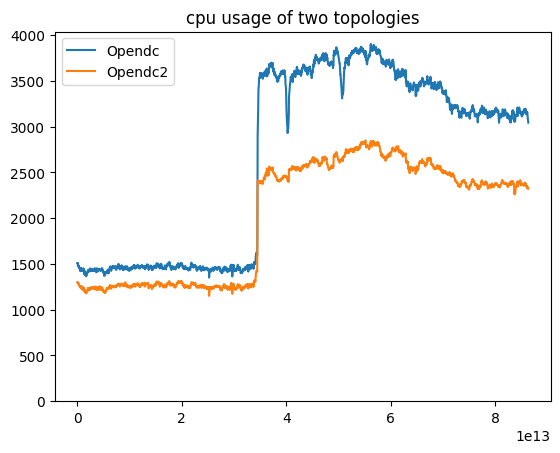

In [20]:
# plt.plot(df_trace.groupby("real_timestamp").agg({"cpu_usage": "sum"}), label="data")
plt.plot(df_host.groupby("real_timestamp").agg({"cpu_usage": "sum"}), label="Opendc")
plt.plot(df_host_2.groupby("real_timestamp").agg({"cpu_usage": "sum"}), label="Opendc2")

plt.title("cpu usage of two topologies")
plt.legend()
plt.ylim([0, None])

plt.show()

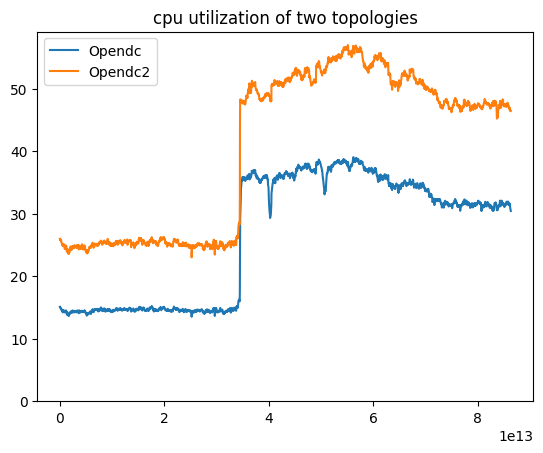

In [21]:
# plt.plot(df_trace.groupby("real_timestamp").agg({"cpu_usage": "sum"}), label="data")
plt.plot(df_host.groupby("real_timestamp").agg({"cpu_utilization": "sum"}), label="Opendc")
plt.plot(df_host_2.groupby("real_timestamp").agg({"cpu_utilization": "sum"}), label="Opendc2")

plt.title("cpu utilization of two topologies")
plt.legend()
plt.ylim([0, None])

plt.show()

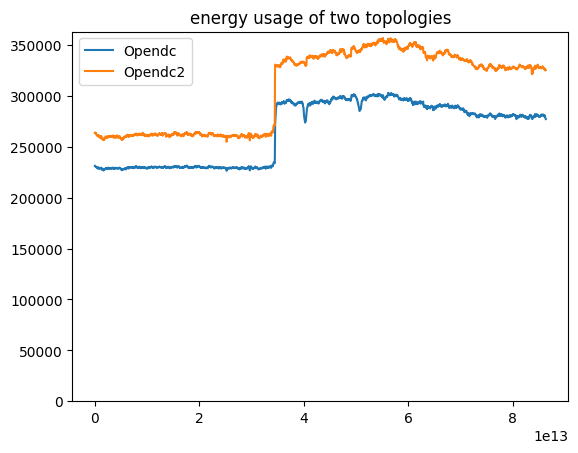

In [23]:
# plt.plot(df_trace.groupby("real_timestamp").agg({"cpu_usage": "sum"}), label="data")
plt.plot(df_host.groupby("real_timestamp").agg({"power_total": "sum"}), label="Opendc")
plt.plot(df_host_2.groupby("real_timestamp").agg({"power_total": "sum"}), label="Opendc2")

plt.title("energy usage of two topologies")
plt.legend()
plt.ylim([0, None])

plt.show()

In [60]:
server_name = "2152362"

df_trace_selected = df_trace[df_trace["id"] == server_name]

df_server_selected = df_server[df_server["server_name"] == server_name]
host_id = df_server_selected["host_id"].unique()[0]

df_host_selected = df_host[df_host["host_id"] == host_id]
df_host_selected_2 = df_host_2[df_host_2["host_id"] == host_id]

In [61]:
host_usage = np.array(df_host_selected.cpu_usage).round(2)
host_usage_2 = np.array(df_host_selected_2.cpu_usage).round(2)

In [57]:
trace_usage = np.array(df_trace_selected.cpu_usage[1:])

/tmp/ipykernel_50093/235196460.py:1: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  trace_usage = np.array(df_trace_selected.cpu_usage[1:])


In [62]:
sum(host_usage - trace_usage)

0.0

In [63]:
sum(host_usage_2 - trace_usage)

0.0

In [64]:
host_usage_2

array([45.91, 45.97, 47.09, ..., 44.36, 43.56, 44.37])

In [72]:
for g,s in df_host.groupby("timestamp"):
    print(sum(s.cpu_usage))
    
    
    break

1506.9900162220001


In [74]:
for g,s in df_host_2.groupby("timestamp"):
    print(sum(s.cpu_usage))
    print(g)
    
    break

1296.0300018787384
1970-01-01 00:00:30+00:00


In [81]:
timestamp = "1970-01-01 00:00:30+00:00"

usage = np.array(df_host[df_host["timestamp"] == timestamp].cpu_usage)

usage_2 = np.array(df_host_2[df_host_2["timestamp"] == timestamp].cpu_usage)

In [92]:
usage - usage_2

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       30.16000366,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , 25.15000153,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       48.12000275,  0.        ,  0.        ,  0.        , 23.26000214,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [88]:
df_host[df_host["timestamp"] == timestamp].iloc[10]

timestamp                        1970-01-01 00:00:30+00:00
host_id               657eecdd-3cb1-3d09-0000-00000000000a
cpu_count                                               16
mem_capacity                                        100000
guests_terminated                                        0
guests_running                                           1
guests_error                                             0
guests_invalid                                           0
cpu_limit                                            100.0
cpu_usage                                        80.160004
cpu_demand                                       80.160004
cpu_utilization                                     0.8016
cpu_time_active                                         24
cpu_time_idle                                            5
cpu_time_steal                                           0
cpu_time_lost                                            0
power_total                                     3604.799

In [87]:
df_host_2[df_host_2["timestamp"] == timestamp].iloc[10]

timestamp                        1970-01-01 00:00:30+00:00
host_id               657eecdd-3cb1-3d09-0000-00000000000a
cpu_count                                               16
mem_capacity                                        100000
guests_terminated                                        0
guests_running                                           1
guests_error                                             0
guests_invalid                                           0
cpu_limit                                             50.0
cpu_usage                                             50.0
cpu_demand                                            50.0
cpu_utilization                                        1.0
cpu_time_active                                         30
cpu_time_idle                                            0
cpu_time_steal                                          18
cpu_time_lost                                            0
power_total                                        4199.

In [89]:
df_server[df_server["host_id"] == "657eecdd-3cb1-3d09-0000-00000000000a"]

,timestamp,server_id,server_name,host_id,mem_capacity,cpu_count,cpu_limit,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,uptime,downtime,provision_time,boot_time,absolute_timestamp
10,1970-01-01 00:00:30+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,1,0,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-09 22:00:00
91,1970-01-01 00:01:00+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,2,0,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-09 22:00:30
172,1970-01-01 00:01:30+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,1,1,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-09 22:01:00
253,1970-01-01 00:02:00+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,2,0,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-09 22:01:30
334,1970-01-01 00:02:30+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,1,0,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-09 22:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331560,1970-01-01 23:58:00+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,0,2,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-10 21:57:30
331690,1970-01-01 23:58:30+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,0,1,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-10 21:58:00
331820,1970-01-01 23:59:00+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,0,2,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-10 21:58:30
331950,1970-01-01 23:59:30+00:00,00000000-0000-0000-edf5-f1d90dca2f6a,2152647,657eecdd-3cb1-3d09-0000-00000000000a,100,16,100.0,0,2,0,0,30000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2022-10-10 21:59:00


In [90]:
df_trace[df_trace["id"] == "2152647"]

,id,timestamp,duration,cpu_count,cpu_usage,real_timestamp
26281,2152647,2022-10-09 22:00:00,30000,16,77.37,0 days 00:00:00
26282,2152647,2022-10-09 22:00:30,30000,16,80.16,0 days 00:00:30
26283,2152647,2022-10-09 22:01:00,30000,16,80.38,0 days 00:01:00
26284,2152647,2022-10-09 22:01:30,30000,16,81.32,0 days 00:01:30
26285,2152647,2022-10-09 22:02:00,30000,16,79.54,0 days 00:02:00
...,...,...,...,...,...,...
29157,2152647,2022-10-10 21:58:00,30000,16,0.77,0 days 23:58:00
29158,2152647,2022-10-10 21:58:30,30000,16,0.47,0 days 23:58:30
29159,2152647,2022-10-10 21:59:00,30000,16,0.28,0 days 23:59:00
29160,2152647,2022-10-10 21:59:30,30000,16,0.17,0 days 23:59:30


In [ ]:
df_host[df_host["id"] == "2152647"]